## 문제 정의: 유방암 진단 with Naive Bayes

02에서 같은 데이터를 KNN으로 풀었다. 여기서는 **나이브 베이즈**로 풀면서,
"데이터 성격에 따라 어떤 NB를 써야 하는가"를 검증한다.

- **목표**: 종양이 악성(malignant)인지 양성(benign)인지 예측
- **문제 유형**: 이진 분류 (0=악성, 1=양성)
- **입력(X)**: 세포핵 측정값 30개 (연속값)
- **출력(y)**: 0=악성, 1=양성
- **평가 기준**: 악성을 놓치면 (False Negative) 치명적
  → 악성 recall 중요 (02와 동일한 의료 맥락)

### 왜 GaussianNB인가?

나이브 베이즈는 피처 분포 가정에 따라 종류가 다르다:
| 종류 | 가정 | 적합 데이터 |
|---|---|---|
| GaussianNB | 정규분포 | **연속값** ← 이 데이터 |
| MultinomialNB | 빈도(0 이상 정수) | 텍스트 단어 수 (03에서 씀) |
| BernoulliNB | 0/1 (있다/없다) | 이진 피처 |

이 데이터는 연속 측정값 30개 → **GaussianNB**가 원칙적으로 맞다.
(03의 MultinomialNB는 음수를 못 받아 표준화한 값엔 직접 못 쓴다.)

### 핵심 질문: 데이터가 정말 정규분포를 따르는가?

GaussianNB는 "각 피처가 정규분포"라고 **가정**한다.
→ 실제로 그런지 **히스토그램 / Q-Q plot으로 먼저 진단**한다.
→ 안 따르면, QuantileTransformer로 분포를 정규화하여 비교한다.

### 검증 방법
- 전처리 3종(원본 / StandardScaler / QuantileTransformer)을 GaussianNB에 적용
- 교차검증(cross_val_score)으로 평균±표준편차 비교 (데이터가 작아 단일 분할은 출렁임)
- 전처리는 Pipeline 안에서 → fold마다 train에만 fit (데이터 누수 방지)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [2]:
bc = load_breast_cancer()
X = bc.data
y = bc.target

df = pd.DataFrame(X, columns=bc.feature_names)
print(df.shape)
df.describe()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


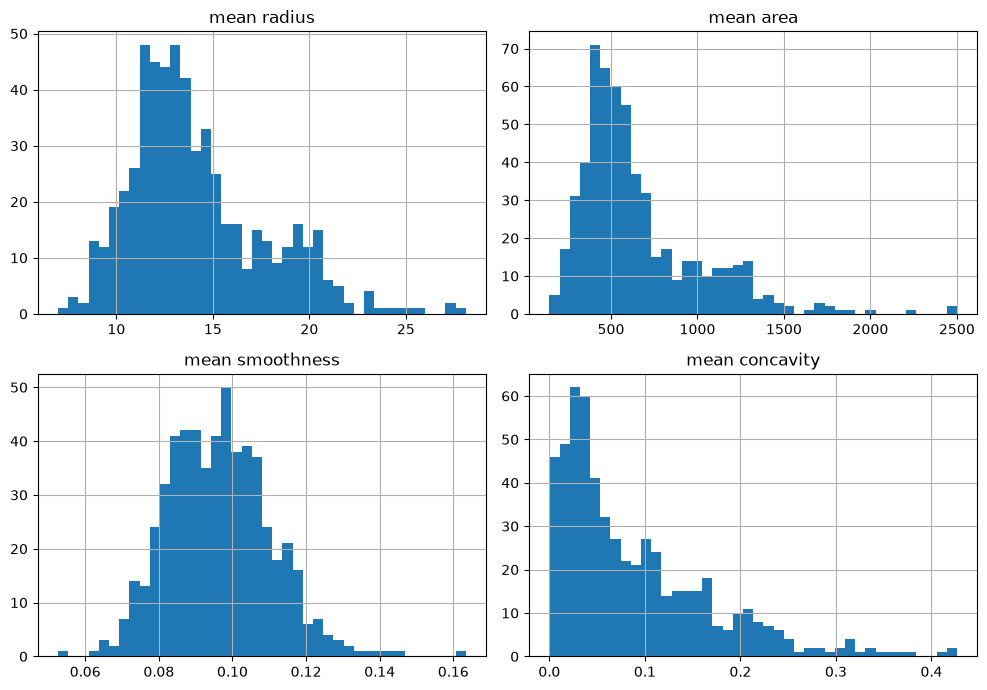

In [4]:
# 대표 피처 몇 개의 분포 확인 
cols = ["mean radius", "mean area", "mean smoothness", "mean concavity"]

df[cols].hist(bins=40, figsize=(10, 7))
plt.tight_layout()
plt.show()

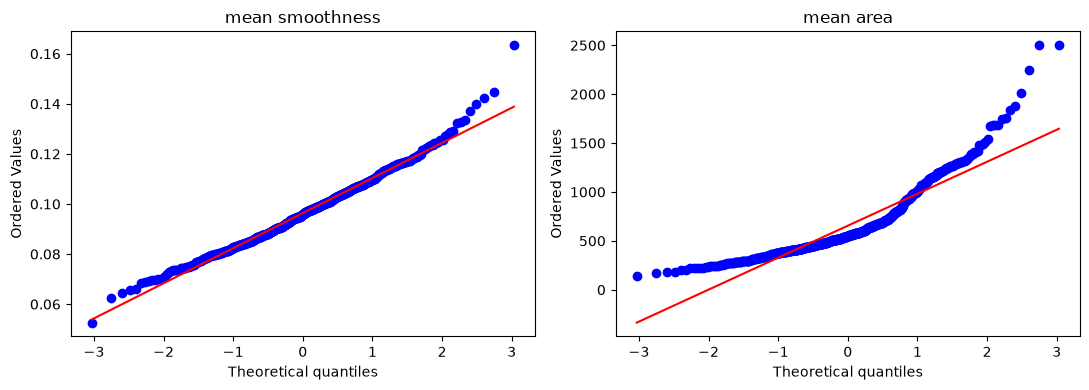

In [7]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

stats.probplot(df["mean smoothness"], dist="norm", plot=axes[0])
axes[0].set_title("mean smoothness")

stats.probplot(df["mean area"], dist="norm", plot=axes[1])
axes[1].set_title("mean area")

plt.tight_layout()
plt.show()

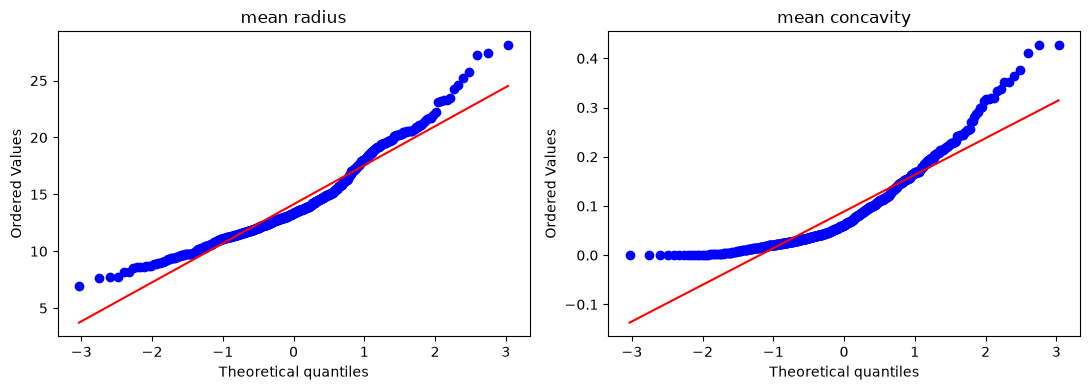

In [8]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

stats.probplot(df["mean radius"], dist="norm", plot=axes[0])
axes[0].set_title("mean radius")

stats.probplot(df["mean concavity"], dist="norm", plot=axes[1])
axes[1].set_title("mean concavity")

plt.tight_layout()
plt.show()

### 진단 결론

- mean smoothness, mean radius: 정규분포에 가까움 ✅
- mean area, mean concavity: 오른쪽으로 치우침 ❌
  (크기/심각도 값이라 0에서 막히고 오른쪽 꼬리가 긺)

→ 데이터가 **부분적으로만** 정규분포를 따른다.
→ GaussianNB의 가정이 일부 위반됨.
→ **처방**: QuantileTransformer로 분포를 정규화하면 개선될지 검증

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [13]:
from sklearn.model_selection import cross_val_score

setups = {
    "원본 (no scaling)": GaussianNB(),
    "StandardScaler": Pipeline([
        ("sc", StandardScaler()),
        ("nb", GaussianNB()),
    ]),
    "QuantileTransformer": Pipeline([
        ("qt", QuantileTransformer(output_distribution="normal", random_state=42)),
        ("nb", GaussianNB()),
    ]),
}

for name, model in setups.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name:22s}: {scores.mean():.4f} ± {scores.std():.4f}")

원본 (no scaling)       : 0.9385 ± 0.0146
StandardScaler        : 0.9279 ± 0.0204
QuantileTransformer   : 0.9385 ± 0.0176


C:\dev\sesac\ml\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(
C:\dev\sesac\ml\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(
C:\dev\sesac\ml\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(
C:\dev\sesac\ml\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (455). n_quantiles is set to n_samples.
  warnings.warn(
C:\dev\sesac\ml\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (456). 

### 여러 NB 비교: 데이터 성격이 모델을 결정한다

각 NB는 가정이 다르므로, **각자 맞는 전처리**를 붙여야 한다.
| NB | 가정 | 맞는 전처리 |
|---|---|---|
| GaussianNB | 정규분포 | QuantileTransformer(normal) |
| MultinomialNB | 0 이상 빈도 | MinMaxScaler (0~1) |
| BernoulliNB | 0/1 | 내장 이진화(binarize) |

가설: 이 데이터는 **연속 측정값**이므로 GaussianNB가 가장 맞고,
나머지는 억지로 맞춘 것이라 성능이 낮을 것이다.


In [14]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


In [15]:
setups = {
    # GaussianNB: 정규분포 가정 → Quantile(normal)으로 분포를 정규화
    # n_quantiles=100: 데이터(569)보다 작게 → 경고 방지
    "GaussianNB + Quantile": Pipeline([
        ("qt", QuantileTransformer(output_distribution="normal",
                                   n_quantiles=100, random_state=42)),
        ("nb", GaussianNB()),
    ]),

    # MultinomialNB: 0 이상 가정 → MinMaxScaler로 0~1 (음수 제거)
    # 단, 연속 측정값이라 "빈도" 가정엔 안 맞음 → 성능 낮을 듯
    "MultinomialNB + MinMax": Pipeline([
        ("mm", MinMaxScaler()),
        ("nb", MultinomialNB()),
    ]),

    # BernoulliNB: 0/1 가정. binarize 기본값(0.0)은 우리 데이터에 안 맞으니
    # MinMaxScaler로 0~1 만든 뒤 중앙값 0.5 기준 이진화
    "BernoulliNB + MinMax": Pipeline([
        ("mm", MinMaxScaler()),
        ("nb", BernoulliNB(binarize=0.5)),   # 0.5 넘으면 1, 아니면 0
    ]),
}

# accuracy와 recall_macro 둘 다 비교 (의료 맥락이라 recall 중요)
for name, model in setups.items():
    acc = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    rec = cross_val_score(model, X, y, cv=5, scoring="recall_macro")
    print(f"{name:24s} | acc {acc.mean():.4f} ± {acc.std():.4f} "
          f"| recall {rec.mean():.4f} ± {rec.std():.4f}")


GaussianNB + Quantile    | acc 0.9385 ± 0.0176 | recall 0.9357 ± 0.0168
MultinomialNB + MinMax   | acc 0.8401 ± 0.0460 | recall 0.7879 ± 0.0594
BernoulliNB + MinMax     | acc 0.9034 ± 0.0259 | recall 0.8781 ± 0.0345


### 결론
- GaussianNB(0.94) > BernoulliNB(0.90) > MultinomialNB(0.84)
- 연속 측정값에는 GaussianNB가 맞다 (정규분포 가정 일치).
- MultinomialNB는 "빈도" 가정이라 억지로 쓰면 성능·안정성 모두 최악.
- 전처리는 모델 가정에 데이터를 맞추는 작업 — 모델마다 다르다.
- 보너스: GaussianNB는 스케일에 무관 (StandardScaler ≈ 원본).
  KNN(02, 거리 기반)과 정반대.
